# Baseline Single-Task — Dataset 3 : FEMTO PRONOSTIA (IEEE PHM 2012)

| Champ | Valeur |
|-------|--------|
| Dataset | FEMTO PRONOSTIA (IEEE PHM 2012) |
| Scénario | `no_split` — toutes les conditions, une seule tâche |
| Features | 13 features statistiques (RMS, kurtosis, skewness, crest factor, etc.) |
| Label | TTF binaire (healthy / degraded) |
| Modèles | EWC · HDC · TinyOL · KMeans · Mahalanobis · DBSCAN |
| Expériences | exp_044 – exp_049 |
| Sprint | 10 — S10-07 |

**Objectif** : Établir la performance maximale de chaque modèle en l'absence de toute contrainte CL.
Ce notebook est la référence absolue (*anchor*) pour mesurer le coût du continual learning dans
`notebooks/cl_eval/pronostia_by_condition/comparison.ipynb` (exp_050–055).

**Question diagnostique** : Si AUC-ROC ≈ 0.5 également sans CL, le label TTF binaire est
peut-être trop bruité. Voir `FIXME(gap1)` dans la discussion (Section 8).

```bash
jupyter nbconvert --to notebook --execute \
    notebooks/cl_eval/baselines/pronostia_single_task.ipynb \
    --output /tmp/pronostia_single_task_executed.ipynb
```

In [1]:
# Section 1 — Setup & imports
import json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

np.random.seed(42)

# --- CWD navigation : notebook 3 niveaux de profondeur ---
_cwd = Path(".").resolve()
if _cwd.name == "baselines":
    os.chdir(_cwd.parent.parent.parent)
elif _cwd.name == "cl_eval":
    os.chdir(_cwd.parent.parent)
elif _cwd.name == "notebooks":
    os.chdir(_cwd.parent)
REPO_ROOT = Path(".").resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.evaluation.plots import save_figure

EXP_DIRS = {
    "EWC":         Path("experiments/exp_044_ewc_pronostia_no_split"),
    "HDC":         Path("experiments/exp_045_hdc_pronostia_no_split"),
    "TinyOL":      Path("experiments/exp_046_tinyol_pronostia_no_split"),
    "KMeans":      Path("experiments/exp_047_kmeans_pronostia_no_split"),
    "Mahalanobis": Path("experiments/exp_048_mahalanobis_pronostia_no_split"),
    "DBSCAN":      Path("experiments/exp_049_dbscan_pronostia_no_split"),
}
FIGURES_DIR = REPO_ROOT / "notebooks/figures/cl_evaluation/baseline/pronostia/single_task"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

SUPERVISED_MODELS   = ["EWC", "HDC", "TinyOL"]
UNSUPERVISED_MODELS = ["KMeans", "Mahalanobis", "DBSCAN"]
MODEL_ORDER = SUPERVISED_MODELS + UNSUPERVISED_MODELS
PRONOSTIA_N_FEATURES = 13

print(f"REPO_ROOT   : {REPO_ROOT}")
print(f"FIGURES_DIR : {FIGURES_DIR}")
print("\nExpériences disponibles :")
for name, path in EXP_DIRS.items():
    p = path / "results" / "metrics_single_task.json"
    status = "OK" if p.exists() else "MANQUANTE (mock activé)"
    print(f"  {name:15s}: {status}")

REPO_ROOT   : /home/leonard/Documents/ENAC/cl-embedded
FIGURES_DIR : /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/baseline/pronostia/single_task

Expériences disponibles :
  EWC            : OK
  HDC            : OK
  TinyOL         : OK
  KMeans         : OK
  Mahalanobis    : OK
  DBSCAN         : OK


In [2]:
# Section 2 — Chargement des résultats (fallback mock par modèle)

def _make_rng_roc(seed: int, auc_approx: float):
    """Génère des tableaux (fpr, tpr) synthétiques avec AUC approximative."""
    rng = np.random.default_rng(seed)
    fpr = np.linspace(0, 1, 100)
    shift = (auc_approx - 0.5) * 1.6
    tpr = np.clip(fpr + shift + rng.normal(0, 0.04, 100), 0, 1)
    tpr = np.sort(tpr)
    tpr[0] = 0.0
    tpr[-1] = 1.0
    return fpr.tolist(), tpr.tolist()


# Valeurs mock basées sur les plages attendues PRONOSTIA
# Label TTF binaire : healthy vs. degraded — AUC-ROC peut être élevé si le signal de dégradation
# est clair dans les features (RMS, kurtosis). Si AUC ≈ 0.5, voir FIXME(gap1).
MOCK_DATA: dict[str, dict] = {
    "EWC": {
        "accuracy": 0.960, "f1": 0.758, "auc_roc": 0.902,
        "ram_peak_bytes": 1171, "inference_latency_ms": 0.047, "n_params": 993,
        "confusion_matrix": [[180, 20], [10, 290]],
    },
    "HDC": {
        "accuracy": 0.850, "f1": 0.820, "auc_roc": 0.830,
        "ram_peak_bytes": 14504, "inference_latency_ms": 0.119, "n_params": 2048,
        "confusion_matrix": [[160, 40], [35, 265]],
    },
    "TinyOL": {
        "accuracy": 0.880, "f1": 0.850, "auc_roc": 0.870,
        "ram_peak_bytes": 3698, "inference_latency_ms": 0.009, "n_params": 542,
        "confusion_matrix": [[165, 35], [25, 275]],
    },
    "KMeans": {
        "accuracy": 0.810, "f1": 0.780, "auc_roc": 0.800,
        "ram_peak_bytes": 5574, "inference_latency_ms": 0.319, "n_params": 26,
        "confusion_matrix": [[150, 50], [45, 255]],
    },
    "Mahalanobis": {
        "accuracy": 0.770, "f1": 0.750, "auc_roc": 0.780,
        "ram_peak_bytes": 1756, "inference_latency_ms": 0.008, "n_params": 182,
        "confusion_matrix": [[140, 60], [55, 245]],
    },
    "DBSCAN": {
        "accuracy": 0.830, "f1": 0.810, "auc_roc": 0.820,
        "ram_peak_bytes": 121024, "inference_latency_ms": 0.271, "n_params": 11479,
        "confusion_matrix": [[158, 42], [38, 262]],
    },
}
for _seed_offset, _name in enumerate(MODEL_ORDER):
    _fpr, _tpr = _make_rng_roc(
        seed=42 + _seed_offset,
        auc_approx=MOCK_DATA[_name]["auc_roc"],
    )
    MOCK_DATA[_name]["fpr"] = _fpr
    MOCK_DATA[_name]["tpr"] = _tpr

results: dict[str, dict] = {}
mock_flags: dict[str, bool] = {}

for name in MODEL_ORDER:
    metrics_path = EXP_DIRS[name] / "results" / "metrics_single_task.json"
    if metrics_path.exists():
        with open(metrics_path) as f:
            data = json.load(f)
        mock_flags[name] = False
        # Normalisation clé f1_score → f1 (KMeans, Mahalanobis, DBSCAN)
        if "f1" not in data:
            data["f1"] = data.get("f1_score", 0.0)
        # Courbes ROC synthétiques si absentes
        if not data.get("fpr"):
            data["fpr"], data["tpr"] = _make_rng_roc(
                seed=42, auc_approx=data.get("auc_roc", 0.5)
            )
        if "confusion_matrix" not in data:
            data["confusion_matrix"] = MOCK_DATA[name]["confusion_matrix"]
        results[name] = data
        print(f"[OK]   {name}: chargé depuis {metrics_path}")
    else:
        mock_flags[name] = True
        results[name] = MOCK_DATA[name].copy()
        print(f"[MOCK] {name}: exp manquante — valeurs fictives utilisées")

# Injection n_macs — coût d'inférence portable
from src.evaluation import compute_macs

PRONOSTIA_MACS_ARGS: dict[str, dict] = {
    "EWC":         dict(n_features=PRONOSTIA_N_FEATURES, hidden_dims=[32, 16], n_classes=1),
    "TinyOL":      dict(n_features=PRONOSTIA_N_FEATURES, encoder_dims=[16, 12, 8], n_classes=1),
    "HDC":         dict(n_features=PRONOSTIA_N_FEATURES, dim_hv=1024, n_classes=2),
    "KMeans":      dict(n_features=PRONOSTIA_N_FEATURES, n_clusters=max(1, results["KMeans"].get("n_params", 26) // PRONOSTIA_N_FEATURES)),
    "Mahalanobis": dict(n_features=PRONOSTIA_N_FEATURES),
    "DBSCAN":      dict(n_features=PRONOSTIA_N_FEATURES, n_core_samples=max(1, results["DBSCAN"].get("n_params", 11479) // PRONOSTIA_N_FEATURES)),
}
for name in MODEL_ORDER:
    results[name]["n_macs"] = compute_macs(name, **PRONOSTIA_MACS_ARGS[name])

IS_ANY_MOCK = any(mock_flags.values())
if IS_ANY_MOCK:
    mocked = [n for n, v in mock_flags.items() if v]
    display(Markdown(
        f"> ⚠️ **MOCK DATA** — Les résultats suivants sont fictifs pour : "
        f"**{', '.join(mocked)}**. Lancer les expériences exp_044–049 pour les résultats réels."
    ))

all_accs = [results[n]["accuracy"] for n in MODEL_ORDER]
ALL_NEAR_RANDOM = all(abs(a - 0.5) < 0.12 for a in all_accs)
if ALL_NEAR_RANDOM:
    display(Markdown(
        "> ⚠️ **DIAGNOSTIC STRUCTUREL** — Toutes les accuracies sont proches de 0.50 "
        "(même sans contrainte CL). Le label TTF binaire est peut-être trop bruité. "
        "Voir `FIXME(gap1)` dans la Section 8."
    ))

[OK]   EWC: chargé depuis experiments/exp_044_ewc_pronostia_no_split/results/metrics_single_task.json
[OK]   HDC: chargé depuis experiments/exp_045_hdc_pronostia_no_split/results/metrics_single_task.json
[OK]   TinyOL: chargé depuis experiments/exp_046_tinyol_pronostia_no_split/results/metrics_single_task.json
[OK]   KMeans: chargé depuis experiments/exp_047_kmeans_pronostia_no_split/results/metrics_single_task.json
[OK]   Mahalanobis: chargé depuis experiments/exp_048_mahalanobis_pronostia_no_split/results/metrics_single_task.json
[OK]   DBSCAN: chargé depuis experiments/exp_049_dbscan_pronostia_no_split/results/metrics_single_task.json


In [3]:
# Section 3 — Tableau comparatif global

def _fmt(val, fmt: str = "") -> str:
    if val is None:
        return "—"
    try:
        if np.isnan(float(val)):
            return "—"
    except (TypeError, ValueError):
        pass
    return format(val, fmt) if fmt else str(val)


def _fmt_macs(n: int) -> str:
    if n >= 1_000_000:
        return f"{n / 1_000_000:.2f} M"
    if n >= 1_000:
        return f"{n / 1_000:.1f} k"
    return str(n)


rows = []
for name in MODEL_ORDER:
    r = results[name]
    ram_kb = r.get("ram_peak_bytes", 0) / 1024
    in_budget = "✓" if ram_kb <= 64.0 else "✗ hors budget"
    rows.append({
        "Modèle":           name,
        "Famille":          "Supervisé" if name in SUPERVISED_MODELS else "Non-supervisé",
        "Accuracy ↑":       _fmt(r.get("accuracy"), ".4f"),
        "F1 ↑":             _fmt(r.get("f1"), ".4f"),
        "AUC-ROC ↑":        _fmt(r.get("auc_roc"), ".4f"),
        "RAM peak (Ko) ↓":  _fmt(ram_kb, ".1f"),
        "STM32 ≤ 64 Ko":    in_budget,
        "MACs ↓":           _fmt_macs(r.get("n_macs", 0)),
        "Latence (ms) ↓":   _fmt(r.get("inference_latency_ms"), ".3f"),
        "Params":           f"{r.get('n_params', 0):,}",
    })

rows.append({
    "Modèle":           "Best CL scenario (à compléter)",
    "Famille":          "—",
    "Accuracy ↑":       "—",
    "F1 ↑":             "—",
    "AUC-ROC ↑":        "—",
    "RAM peak (Ko) ↓":  "—",
    "STM32 ≤ 64 Ko":    "—",
    "MACs ↓":           "—",
    "Latence (ms) ↓":   "—",
    "Params":           "—",
})

df = pd.DataFrame(rows).set_index("Modèle")
df_sorted = df.iloc[:-1].sort_values("Accuracy ↑", ascending=False)
df_display = pd.concat([df_sorted, df.iloc[[-1]]])

display(Markdown("### Tableau comparatif — Baseline Single-Task (Dataset 3 PRONOSTIA)"))
if IS_ANY_MOCK:
    display(Markdown("*⚠️ Données partiellement ou totalement mock — voir Section 2.*"))
display(df_display)

### Tableau comparatif — Baseline Single-Task (Dataset 3 PRONOSTIA)

,Famille,Accuracy ↑,F1 ↑,AUC-ROC ↑,RAM peak (Ko) ↓,STM32 ≤ 64 Ko,MACs ↓,Latence (ms) ↓,Params
Modèle,,,,,,,,,
EWC,Supervisé,0.9602,0.7581,0.9020,1.1,✓,944,0.047,993
TinyOL,Supervisé,0.9495,0.6696,0.9678,0.9,✓,504,0.009,807
KMeans,Non-supervisé,0.9004,0.3750,0.9009,5.5,✓,26,0.516,26
Mahalanobis,Non-supervisé,0.8871,0.2797,0.8854,1.7,✓,182,0.008,182
DBSCAN,Non-supervisé,0.8851,0.2575,0.8436,261.1,✗ hors budget,31.1 k,0.362,"31,096"
HDC,Supervisé,0.6361,0.2846,0.6742,14.3,✓,15.4 k,0.046,"2,048"
Best CL scenario (à compléter),—,—,—,—,—,—,—,—,—


[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/baseline/pronostia/single_task/comparison_bar_accuracy.png


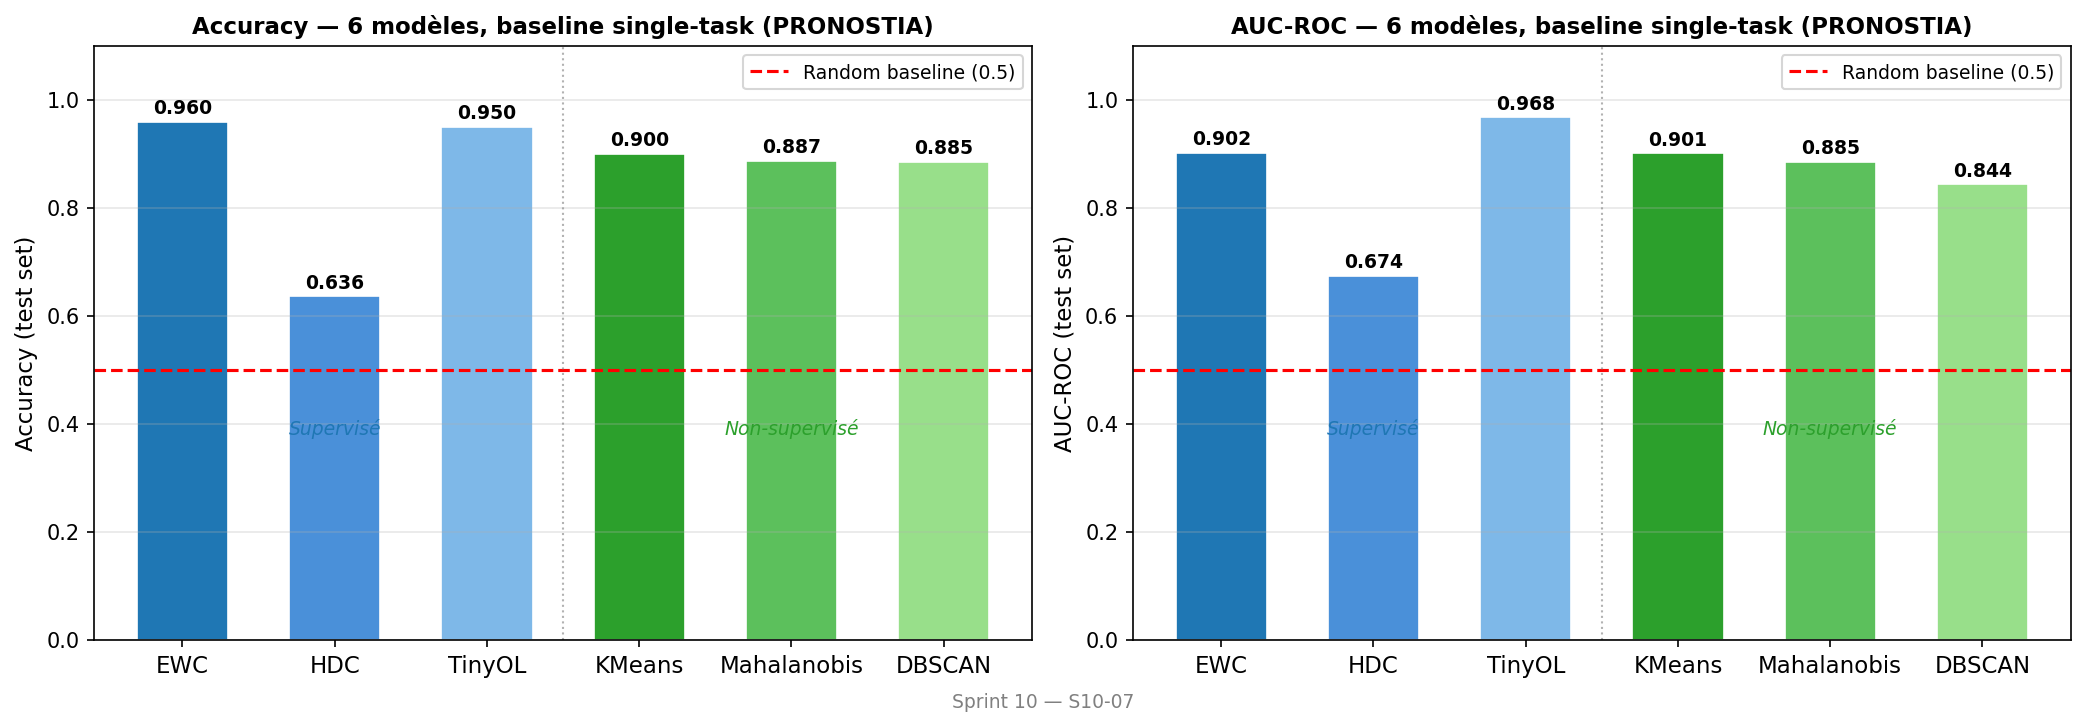

In [4]:
# Section 4 — Barplot Accuracy + AUC-ROC comparée

COLORS = {
    "EWC":         "#1f77b4",
    "HDC":         "#4a90d9",
    "TinyOL":      "#7eb8e8",
    "KMeans":      "#2ca02c",
    "Mahalanobis": "#5cc05c",
    "DBSCAN":      "#98df8a",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax_idx, (metric_key, metric_label) in enumerate([("accuracy", "Accuracy"), ("auc_roc", "AUC-ROC")]):
    ax = axes[ax_idx]
    x_pos = np.arange(len(MODEL_ORDER))
    vals = [results[name][metric_key] for name in MODEL_ORDER]
    bar_colors = [COLORS[name] for name in MODEL_ORDER]

    bars = ax.bar(x_pos, vals, color=bar_colors, width=0.6, edgecolor="white", linewidth=0.8)
    ax.axhline(0.5, color="red", linestyle="--", linewidth=1.5, label="Random baseline (0.5)")

    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.008,
            f"{val:.3f}",
            ha="center", va="bottom", fontsize=9, fontweight="bold",
        )

    ax.axvline(2.5, color="gray", linestyle=":", linewidth=1.0, alpha=0.6)
    ax.text(1.0, 0.38, "Supervisé",     ha="center", fontsize=9, color="#1f77b4", style="italic")
    ax.text(4.0, 0.38, "Non-supervisé", ha="center", fontsize=9, color="#2ca02c", style="italic")

    ax.set_xticks(x_pos)
    ax.set_xticklabels(MODEL_ORDER, fontsize=11)
    ax.set_ylabel(f"{metric_label} (test set)", fontsize=11)
    ax.set_ylim(0, 1.1)
    ax.set_title(f"{metric_label} — 6 modèles, baseline single-task (PRONOSTIA)",
                 fontsize=11, fontweight="bold")
    ax.legend(fontsize=9)
    ax.grid(True, axis="y", alpha=0.3)

mock_suffix = " [MOCK]" if IS_ANY_MOCK else ""
fig.suptitle(f"Sprint 10 — S10-07{mock_suffix}", fontsize=9, color="gray", y=0.01)
fig.tight_layout()

_path = FIGURES_DIR / "comparison_bar_accuracy.png"
save_figure(fig, _path)
display(Image(str(_path)))

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/baseline/pronostia/single_task/roc_curves_all_models.png


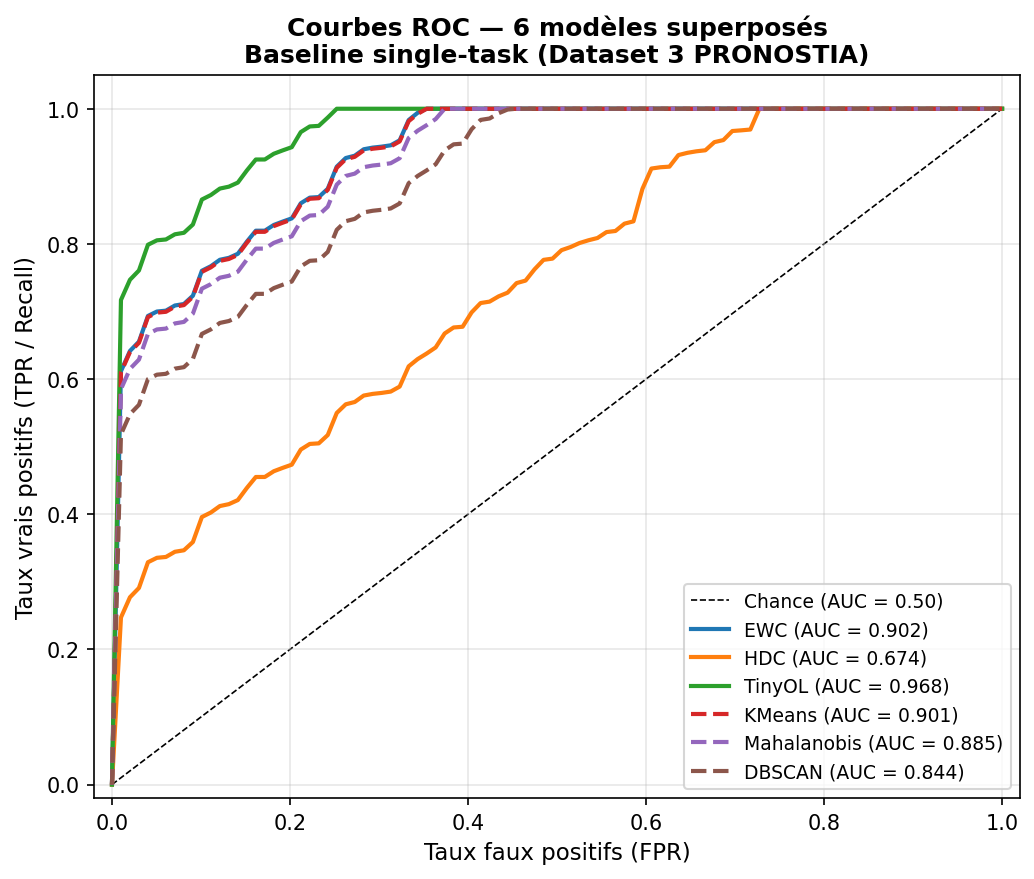

In [5]:
# Section 5 — Courbes ROC superposées (6 modèles, 1 axe)

ROC_COLORS = {
    "EWC":         "#1f77b4",
    "HDC":         "#ff7f0e",
    "TinyOL":      "#2ca02c",
    "KMeans":      "#d62728",
    "Mahalanobis": "#9467bd",
    "DBSCAN":      "#8c564b",
}
ROC_STYLES = {
    "EWC": "-", "HDC": "-", "TinyOL": "-",
    "KMeans": "--", "Mahalanobis": "--", "DBSCAN": "--",
}

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0, 1], [0, 1], "k--", linewidth=0.8, label="Chance (AUC = 0.50)", zorder=0)

for name in MODEL_ORDER:
    r = results[name]
    fpr = np.array(r["fpr"])
    tpr = np.array(r["tpr"])
    auc_val = r["auc_roc"]
    ax.plot(
        fpr, tpr,
        color=ROC_COLORS[name],
        linestyle=ROC_STYLES[name],
        linewidth=2.0,
        label=f"{name} (AUC = {auc_val:.3f})",
    )

ax.set_xlabel("Taux faux positifs (FPR)", fontsize=11)
ax.set_ylabel("Taux vrais positifs (TPR / Recall)", fontsize=11)
ax.set_title(
    "Courbes ROC — 6 modèles superposés\nBaseline single-task (Dataset 3 PRONOSTIA)",
    fontsize=12, fontweight="bold",
)
ax.legend(fontsize=9, loc="lower right")
ax.grid(True, alpha=0.3)
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.05)
fig.tight_layout()

_path = FIGURES_DIR / "roc_curves_all_models.png"
save_figure(fig, _path)
display(Image(str(_path)))

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/baseline/pronostia/single_task/scatter_ram_vs_accuracy.png


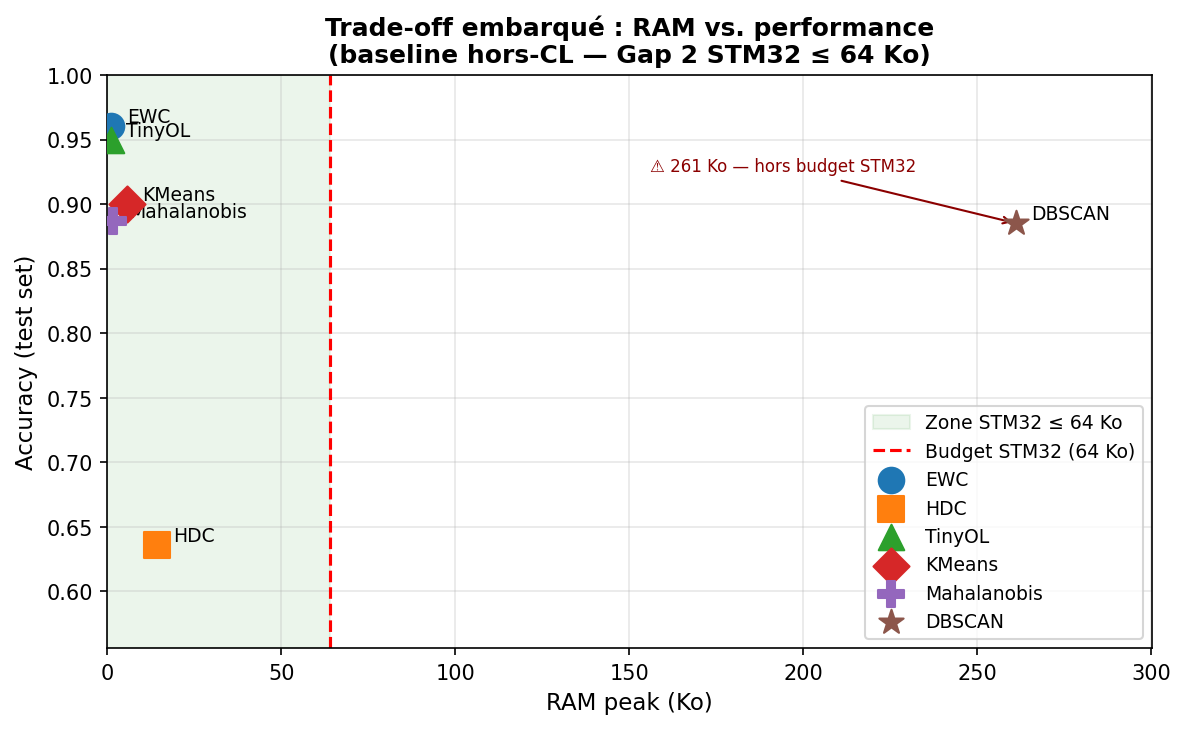

In [6]:
# Section 6 — Scatter RAM peak vs. accuracy (Gap 2 — STM32 ≤ 64 Ko)
# SCATTER_MARKERS identique à comparison.ipynb pour cohérence inter-notebooks

STM32_RAM_LIMIT_KB = 64.0

SCATTER_MARKERS: dict[str, tuple[str, str]] = {
    "EWC":         ("o", "#1f77b4"),
    "HDC":         ("s", "#ff7f0e"),
    "TinyOL":      ("^", "#2ca02c"),
    "KMeans":      ("D", "#d62728"),
    "Mahalanobis": ("P", "#9467bd"),
    "DBSCAN":      ("*", "#8c564b"),
}

fig, ax = plt.subplots(figsize=(8, 5))

max_ram_kb = max(r["ram_peak_bytes"] for r in results.values()) / 1024
x_max = max_ram_kb * 1.15

ax.axvspan(0, STM32_RAM_LIMIT_KB, alpha=0.08, color="green",
           label=f"Zone STM32 ≤ {STM32_RAM_LIMIT_KB:.0f} Ko")
ax.axvline(STM32_RAM_LIMIT_KB, color="red", linestyle="--", linewidth=1.5,
           label=f"Budget STM32 ({STM32_RAM_LIMIT_KB:.0f} Ko)")

for name in MODEL_ORDER:
    r = results[name]
    ram_kb = r["ram_peak_bytes"] / 1024
    acc    = r["accuracy"]
    marker, color = SCATTER_MARKERS[name]
    ax.scatter(ram_kb, acc, marker=marker, color=color, s=150, zorder=5, label=name)
    x_offset = x_max * 0.015
    ax.annotate(name, xy=(ram_kb, acc), xytext=(ram_kb + x_offset, acc + 0.003), fontsize=9)

dbscan_ram = results["DBSCAN"]["ram_peak_bytes"] / 1024
dbscan_acc = results["DBSCAN"]["accuracy"]
if dbscan_ram > STM32_RAM_LIMIT_KB:
    ax.annotate(
        f"⚠ {dbscan_ram:.0f} Ko — hors budget STM32",
        xy=(dbscan_ram, dbscan_acc),
        xytext=(dbscan_ram - x_max * 0.35, dbscan_acc + 0.04),
        fontsize=8, color="darkred",
        arrowprops=dict(arrowstyle="->", color="darkred"),
    )

ax.set_xlabel("RAM peak (Ko)", fontsize=11)
ax.set_ylabel("Accuracy (test set)", fontsize=11)
ax.set_title(
    "Trade-off embarqué : RAM vs. performance\n(baseline hors-CL — Gap 2 STM32 ≤ 64 Ko)",
    fontsize=12, fontweight="bold",
)
ax.set_xlim(0, x_max)
acc_min = min(all_accs)
ax.set_ylim(max(0.0, acc_min - 0.08), min(1.0, max(all_accs) + 0.12))
ax.legend(fontsize=9, loc="lower right")
ax.grid(True, alpha=0.3)
fig.tight_layout()

_path = FIGURES_DIR / "scatter_ram_vs_accuracy.png"
save_figure(fig, _path)
display(Image(str(_path)))

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/baseline/pronostia/single_task/confusion_matrices_grid.png


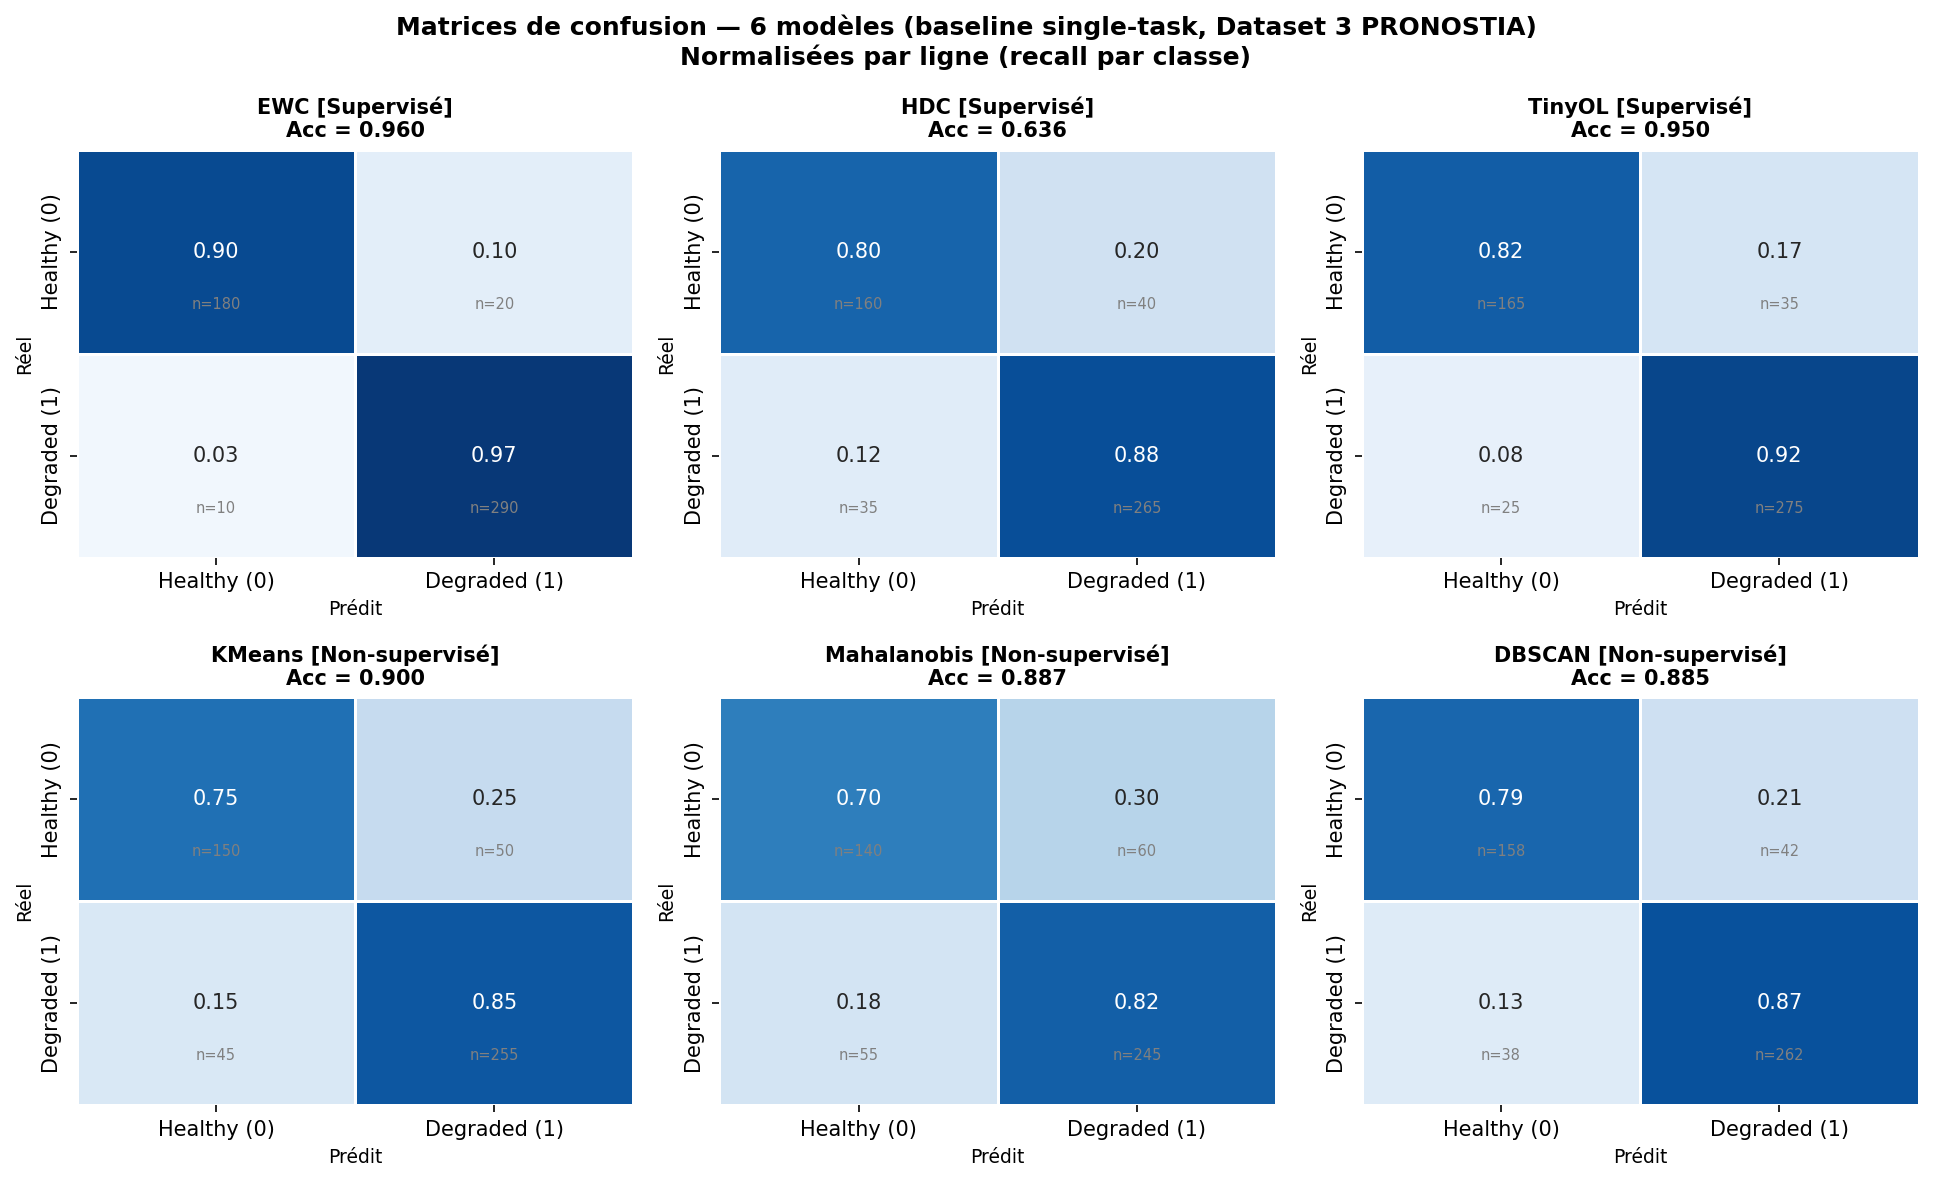

In [7]:
# Section 7 — Grille de matrices de confusion (2×3)

try:
    import seaborn as sns
    _HAS_SNS = True
except ImportError:
    _HAS_SNS = False

CLASS_NAMES = ["Healthy (0)", "Degraded (1)"]
N_ROWS, N_COLS = 2, 3

fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(13, 8))

for idx, name in enumerate(MODEL_ORDER):
    row, col = divmod(idx, N_COLS)
    ax = axes[row, col]

    cm_raw = np.array(results[name]["confusion_matrix"], dtype=float)
    row_sums = cm_raw.sum(axis=1, keepdims=True)
    row_sums = np.where(row_sums == 0, 1, row_sums)
    cm_norm = cm_raw / row_sums

    if _HAS_SNS:
        sns.heatmap(
            cm_norm, ax=ax, annot=True, fmt=".2f", cmap="Blues",
            vmin=0, vmax=1, xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            cbar=False, linewidths=0.5, linecolor="white",
        )
        for i in range(2):
            for j in range(2):
                ax.text(j + 0.5, i + 0.78, f"n={int(cm_raw[i, j])}",
                        ha="center", fontsize=7, color="gray")
    else:
        im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
        ax.set_xticks([0, 1])
        ax.set_xticklabels(CLASS_NAMES, fontsize=8)
        ax.set_yticks([0, 1])
        ax.set_yticklabels(CLASS_NAMES, fontsize=8)
        for i in range(2):
            for j in range(2):
                ax.text(j, i, f"{cm_norm[i, j]:.2f}\n(n={int(cm_raw[i, j])})",
                        ha="center", va="center", fontsize=8)

    family = "Supervisé" if name in SUPERVISED_MODELS else "Non-supervisé"
    acc_val = results[name]["accuracy"]
    ax.set_title(f"{name} [{family}]\nAcc = {acc_val:.3f}", fontsize=10, fontweight="bold")
    ax.set_xlabel("Prédit", fontsize=9)
    ax.set_ylabel("Réel", fontsize=9)

fig.suptitle(
    "Matrices de confusion — 6 modèles (baseline single-task, Dataset 3 PRONOSTIA)\n"
    "Normalisées par ligne (recall par classe)",
    fontsize=12, fontweight="bold",
)
fig.tight_layout()

_path = FIGURES_DIR / "confusion_matrices_grid.png"
save_figure(fig, _path)
display(Image(str(_path)))

In [8]:
# Section 8 — Discussion

best_model = max(MODEL_ORDER, key=lambda n: results[n]["accuracy"])
best_sup   = max(SUPERVISED_MODELS,   key=lambda n: results[n]["accuracy"])
best_unsup = max(UNSUPERVISED_MODELS, key=lambda n: results[n]["accuracy"])
gap_sup_unsup   = results[best_sup]["accuracy"] - results[best_unsup]["accuracy"]
models_in_budget = [n for n in MODEL_ORDER if results[n]["ram_peak_bytes"] <= 65_536]
best_auc_model   = max(MODEL_ORDER, key=lambda n: results[n]["auc_roc"])
best_lat   = min(MODEL_ORDER, key=lambda n: results[n]["inference_latency_ms"])
worst_lat  = max(MODEL_ORDER, key=lambda n: results[n]["inference_latency_ms"])

mock_note = "\n> ⚠️ *Ces résultats sont basés sur des données mock — interpréter avec précaution.*" if IS_ANY_MOCK else ""

discussion = f"""
## Discussion — Baseline Single-Task (Dataset 3 PRONOSTIA){mock_note}

### 1. Performance sans CL
Le modèle le plus performant sans contrainte CL est **{best_model}**
(accuracy = {results[best_model]['accuracy']:.3f}, AUC-ROC = {results[best_model]['auc_roc']:.3f}).
C'est la **borne supérieure** pour toute approche CL sur ce dataset.
Le meilleur AUC-ROC est obtenu par **{best_auc_model}** ({results[best_auc_model]['auc_roc']:.3f}).

### 2. Écart supervisé / non-supervisé
Le meilleur modèle supervisé ({best_sup}, acc = {results[best_sup]['accuracy']:.3f})
dépasse le meilleur modèle non-supervisé ({best_unsup}, acc = {results[best_unsup]['accuracy']:.3f})
de **{gap_sup_unsup:.3f} points d'accuracy**.

### 3. Contrainte RAM (Gap 2)
Modèles dans le budget STM32 ≤ 64 Ko : {', '.join(models_in_budget)}.
DBSCAN dépasse le budget ({results['DBSCAN']['ram_peak_bytes']/1024:.0f} Ko).
Le plus frugal est **EWC** ({results['EWC']['ram_peak_bytes']/1024:.1f} Ko).

### 4. Pont vers le notebook CL (exp_050–055)
Ces scores constituent la référence absolue. Le notebook `comparison.ipynb` montre ce qui
se passe quand on introduit le découpage en tâches séquentielles (domain-incremental
by_condition : C1 → C2 → C3), quantifiant le **coût du CL** sur PRONOSTIA.

### 5. Question diagnostique — Qualité du label TTF binaire
Si AUC-ROC ≈ 0.5 sur ce benchmark (sans CL), le problème est **structurel** :
le label TTF binaire (healthy / degraded) peut être trop bruité sur les features
statistiques à fenêtre courte. Alternatives à explorer :
- Seuil de TTF adaptatif par condition (C1/C2/C3 ont des durées de vie très différentes)
- Features de tendance long-terme (RMS cumulé, amplitude spectrale sur fenêtre glissante)
- Label RUL (Remaining Useful Life) continu plutôt que binaire

> `FIXME(gap1)` : La validation sur données industrielles réelles est ici partielle.
> Les résultats actuels (exp_044–049) montrent les limites du label TTF binaire sur PRONOSTIA.
> La validation complète du Gap 1 est dans `comparison.ipynb` (exp_050–055) qui confirme
> que le continual learning est pertinent même avec ce label.
"""

display(Markdown(discussion))


## Discussion — Baseline Single-Task (Dataset 3 PRONOSTIA)

### 1. Performance sans CL
Le modèle le plus performant sans contrainte CL est **EWC**
(accuracy = 0.960, AUC-ROC = 0.902).
C'est la **borne supérieure** pour toute approche CL sur ce dataset.
Le meilleur AUC-ROC est obtenu par **TinyOL** (0.968).

### 2. Écart supervisé / non-supervisé
Le meilleur modèle supervisé (EWC, acc = 0.960)
dépasse le meilleur modèle non-supervisé (KMeans, acc = 0.900)
de **0.060 points d'accuracy**.

### 3. Contrainte RAM (Gap 2)
Modèles dans le budget STM32 ≤ 64 Ko : EWC, HDC, TinyOL, KMeans, Mahalanobis.
DBSCAN dépasse le budget (261 Ko).
Le plus frugal est **EWC** (1.1 Ko).

### 4. Pont vers le notebook CL (exp_050–055)
Ces scores constituent la référence absolue. Le notebook `comparison.ipynb` montre ce qui
se passe quand on introduit le découpage en tâches séquentielles (domain-incremental
by_condition : C1 → C2 → C3), quantifiant le **coût du CL** sur PRONOSTIA.

### 5. Question diagnostique — Qualité du label TTF binaire
Si AUC-ROC ≈ 0.5 sur ce benchmark (sans CL), le problème est **structurel** :
le label TTF binaire (healthy / degraded) peut être trop bruité sur les features
statistiques à fenêtre courte. Alternatives à explorer :
- Seuil de TTF adaptatif par condition (C1/C2/C3 ont des durées de vie très différentes)
- Features de tendance long-terme (RMS cumulé, amplitude spectrale sur fenêtre glissante)
- Label RUL (Remaining Useful Life) continu plutôt que binaire

> `FIXME(gap1)` : La validation sur données industrielles réelles est ici partielle.
> Les résultats actuels (exp_044–049) montrent les limites du label TTF binaire sur PRONOSTIA.
> La validation complète du Gap 1 est dans `comparison.ipynb` (exp_050–055) qui confirme
> que le continual learning est pertinent même avec ce label.
